In [1]:
import pennylane as qp
qml = qp
import numpy as np

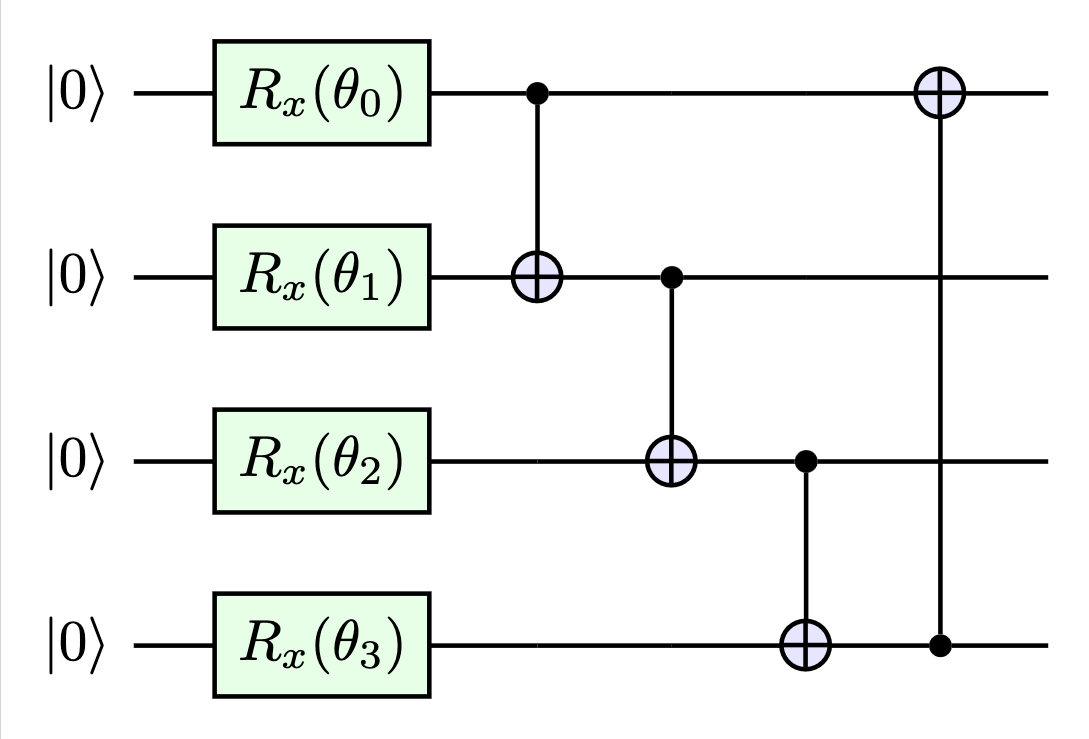

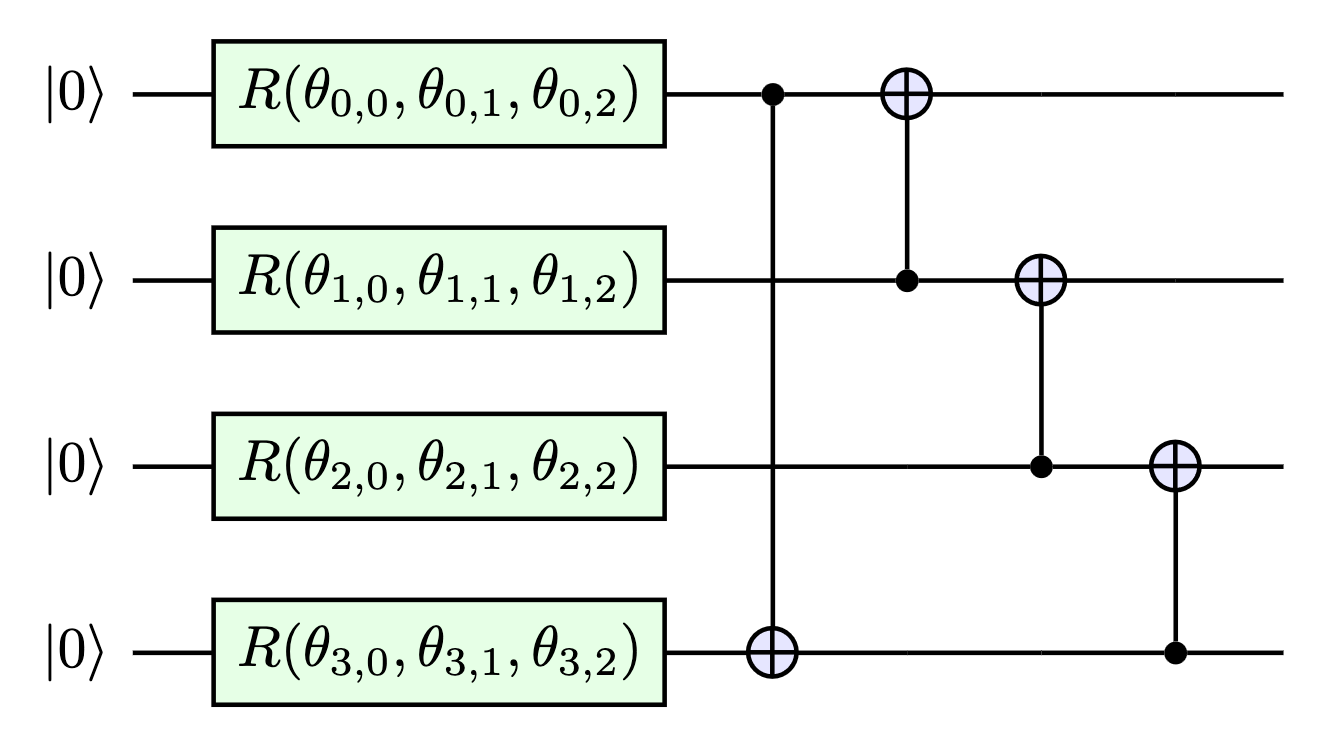

In [2]:
n_bits = 4
dev = qp.device("default.qubit", wires=n_bits)

@qp.qnode(dev)
def basic_entangling_ansatz(observable, params):
    """Applies an ansatz with basic entanglement.

    Args:
        observable (qp.op): a pennylane operator whose expectation value we want to measure.
        params(np.array): an array with the trainable parameters of the ansatz. They have the shape of `qp.BasicEntanglerLayers.shape(n_layers=1, n_wires=n_bits)`

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the expectation value of the given observable.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    qp.BasicEntanglerLayers(weights=params, wires=range(n_bits))
    
    return qp.expval(observable)

@qp.qnode(dev)
def strongly_entangling_ansatz(observable, params):
    """Applies an ansatz with moderate entanglement.

    Args:
        observable (qp.op): a pennylane operator whose expectation value we want to measure.
        params(np.array): an array with the trainable parameters of the ansatz. They have the shape of `qp.StronglyEntanglingLayers.shape(n_layers=1, n_wires=n_bits)`

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the expectation value of the given observable.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    qp.StronglyEntanglingLayers(weights=params, ranges=[3], wires=range(n_bits))
    
    return qp.expval(observable)

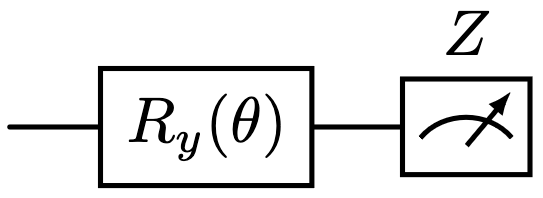

In [3]:
dev = qp.device('default.qubit', wires=1)

# Define the quantum circuit with a parameterized RY gate
@qp.qnode(dev)
def circuit_to_differentiate(theta):
    """Quantum circuit we want to differentiate.

    Args:
        theta (float): parameter of the circuit with respect to which we differentiate.

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the expectation value of Z
    """
    ##################
    # YOUR CODE HERE #
    ##################
    qp.RY(theta, wires=0)
    
    return qp.expval(qp.PauliZ(0))

# Define the parameter-shift rule function
def parameter_shift_rule(theta):
    """Function that applies the parameter shift rule to `circuit_to_differentiate` with respect to the parameter theta.

    Args:
        theta (float): parameter of the circuit with respect to which we differentiate.

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the derivative of the circuit with respect to theta.
    """    
    ##################
    # YOUR CODE HERE #
    ##################
    return (circuit_to_differentiate(theta+np.pi/2) - circuit_to_differentiate(theta-np.pi/2))/2

In [4]:
# Define the built-in parameter-shift rule function
def parameter_shift_rule_built_in(circuit, theta):
    """Function that applies the PennyLane built-in parameter shift rule to a specific circuit with respect to the parameter theta.

    Args:
        circuit (qp.QNode): quantum circuit we want to differentiate.
        theta (float): parameter of the circuit with respect to which we differentiate.

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the derivative of the circuit with respect to theta.
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    return qp.gradients.param_shift(circuit)(theta)

# Define the built-in classical_jacobian function
def jacobian_built_in(circuit, theta):
    """Function that applies the PennyLane built-in jacobian method to a specific circuit with respect to the parameter theta.

    Args:
        circuit (qp.QNode): quantum circuit we want to differentiate.
        theta (float): parameter of the circuit with respect to which we differentiate.

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the derivative of the circuit with respect to theta.
    """  
    ##################
    # YOUR CODE HERE #
    ################## 
    return qp.jacobian(circuit)(theta)

In [ ]:
def gradient_descent_optimization(quantum_circuit, initial_theta, learning_rate, max_iterations):
    """
    Performs Gradient Descent optimization to find the optimal parameter theta
    for a quantum circuit to minimize its output expectation value.

    Args:
        quantum_circuit (qp.QNode): A quantum circuit that depends of a parameter.
        initial_theta (np.array): An array with the initial value of the trainable parameter theta.
        learning_rate (float): Learning rate for the gradient descent update.
        max_iterations (int): Maximum number of iterations for the optimization.

    Returns:
        (np.array): A numpy array of 1 element corresponding to the optimized parameter theta.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    theta = initial_theta
    
    for _ in range(max_iterations):
        gradient = qp.gradients.param_shift(quantum_circuit)(theta)
        theta -= learning_rate * gradient
        
    return theta

optimized_theta = gradient_descent_optimization(circuit, np.array(0.1, requires_grad=True), 0.3, 50)
print(f"Optimized theta using Gradient Descent: {optimized_theta}")
print(f"Expectation value of quantum circuit at optimized theta: {circuit(optimized_theta)}")

In [ ]:
def gradient_descent_optimization_built_in(quantum_circuit, initial_theta, learning_rate, max_iterations):
    """
    Implements Gradient Descent optimization method of PennyLane to find the optimal parameter theta
    for a quantum circuit to minimize its output expectation value.

    Args:
        quantum_circuit (qp.QNode): A quantum circuit that depends of a parameter.
        initial_theta (np.array): An array with the initial value of the trainable parameter theta.
        learning_rate (float): Learning rate for the gradient descent update.
        max_iterations (int): Maximum number of iterations for the optimization.

    Returns:
        (np.array): A numpy array of 1 element corresponding to the optimized parameter theta.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    optimizer = qp.GradientDescentOptimizer(stepsize = learning_rate)
    theta = initial_theta
    
    for _ in range(max_iterations):
        theta = optimizer.step(quantum_circuit, theta)
        
    return theta

optimized_theta = gradient_descent_optimization_built_in(circuit, np.array(0.1, requires_grad=True), 0.3, 50)
print(f"Optimized theta using built-in Gradient Descent: {optimized_theta}")
print(f"Expectation value of quantum circuit at optimized theta: {circuit(optimized_theta)}")

In [ ]:
def cost_function(observable, params):
    """Computes the cost function we want to minimize.

    Args:
        observable (qp.Hamiltonian): a pennylane Hamiltonian whose expectation value we want to measure.
        params(np.array): an array with the trainable parameters of the ansatz.

    Returns:
        (np.tensor): a numpy tensor of 1 element corresponding to the cost function value
    """
    ##################
    # YOUR CODE HERE #
    ##################
    
    return strongly_entangling_ansatz(observable, params)
    
def optimizer(observable, params):
    """Updates the parameters to minimize the cost function value.

    Args:
        observable (qp.Hamiltonian): a pennylane Hamiltonian whose expectation value we want to measure.
        params(np.array): an array with the trainable parameters of the ansatz.

    Returns:
        (np.array): an array with the optimized trainable parameters.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    opt = qp.AdamOptimizer(stepsize = 0.1)

    for _ in range(100):
        params = opt.step(lambda p: cost_function(observable, p), params)
    
    return params